In [1]:
# Standard analytics packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# Import useful packages from sklearn
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

import datetime
from datetime import date

# Load Cleaned Dataset


1.   df -> cleaned dataset


In [2]:
df = pd.read_csv('https://docs.google.com/uc?export=download&id=1uta2GHiSIDF3dXTcfM1YjsD1UWhOBZv7', header=0)
df.head()

,Name,City Found,Times Taken Into Shelter,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color,Outcome Type,Stay_days,Year,Month,Day,Hour,Season
0,Name,Austin (TX),1,Stray,Normal,Dog,Spayed Female,7.0,Border Terrier/Border Collie,White/Tan,Return to Owner,0.325000,2013,10,1,7,Fall
1,Name,Austin (TX),1,Stray,Injured,Dog,Intact Female,3.0,Pit Bull Mix,Blue/White,Euthanasia,0.277778,2013,10,1,8,Fall
2,NoName,Austin (TX),1,Stray,Injured,Dog,Intact Male,8.0,Border Collie Mix,Black/White,Euthanasia,0.355556,2013,10,1,10,Fall
3,Name,Austin (TX),1,Owner Surrender,Normal,Cat,Neutered Male,17.0,Domestic Shorthair Mix,Brown Tabby/White,Transfer,9.095833,2013,10,1,10,Fall
4,Name,Travis (TX),1,Stray,Normal,Dog,Intact Female,4.0,Podengo Pequeno Mix,Black,Adoption,23.104167,2013,10,1,11,Fall


In [3]:
df.shape

(151961, 17)

In [4]:
df_35Cutoff = df[df["Stay_days"]<=35]
df_60Cutoff = df[df["Stay_days"]<=60]
df_15Cutoff = df[df["Stay_days"]<=15]

In [5]:
print("Cutoff 15 shape: ", df_15Cutoff.shape)
print("Cutoff 35 shape: ", df_35Cutoff.shape)
print("Cutoff 60 shape: ", df_60Cutoff.shape)

Cutoff 15 shape:  (104915, 17)
Cutoff 35 shape:  (124433, 17)
Cutoff 60 shape:  (137517, 17)


## Train Test Split


1.   y_train has to components, "Stay_days" "Outcome Type"
2.   0.8/0.2 split



In [6]:
X_train, X_test, y_train, y_test = train_test_split(df_35Cutoff.drop(columns=['Stay_days', 'Outcome Type']),
                                                    df_35Cutoff[["Stay_days", "Outcome Type"]],
                                                    test_size = 0.2,
                                                    random_state = 0)

In [7]:
# Stay_days GT
y_train_st = y_train["Stay_days"]
y_test_st = y_test["Stay_days"]

# Outcome_type GT
y_train_ot = y_train["Outcome Type"]
y_test_ot = y_test["Outcome Type"]

In [8]:
y_train_ot.value_counts()

,count
Outcome Type,
Adoption,44023
Transfer,30735
Return to Owner,19885
Euthanasia,3046
Rto-Adopt,871
Died,815
Disposal,137
Missing,28
Relocate,3


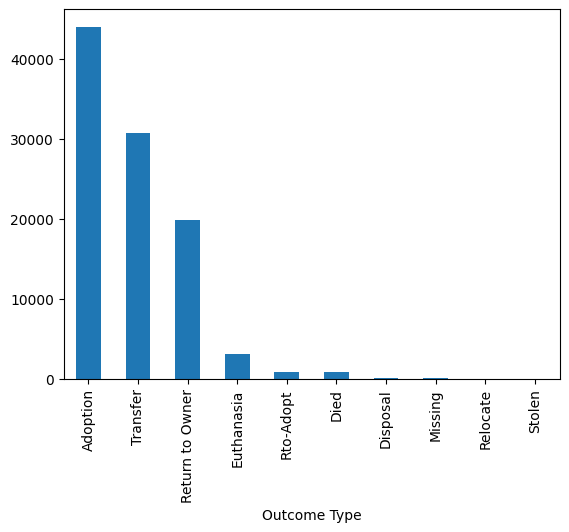

In [9]:
y_train_ot.value_counts().plot(kind='bar')
plt.show()

# EDA



### Feature Types, and Counts

In [10]:
raw_feature_list = X_train.columns.to_list()
print("Raw feature lists: ", raw_feature_list)

Raw feature lists:  ['Name', 'City Found', 'Times Taken Into Shelter', 'Intake Type', 'Intake Condition', 'Animal Type', 'Sex upon Intake', 'Age upon Intake', 'Breed', 'Color', 'Year', 'Month', 'Day', 'Hour', 'Season']


### Categorical Variables

In [11]:
# Categorical Features Unique Values
print("Different Values for City Found: ", len(X_train['City Found'].unique()))
print("Different Values for Intake Type: ", len(X_train['Intake Type'].unique()))
print("Different Values for Intake Condition: ", len(X_train['Intake Condition'].unique()))
print("Different Values for Animal Type: ", len(X_train['Animal Type'].unique()))
print("Different Values for Sex upon Intake: ", len(X_train['Sex upon Intake'].unique()))
print("Different Values for Breed: ", len(X_train['Breed'].unique()))
print("Different Values for Color: ", len(X_train['Color'].unique()))
print("Different Values for Year: ", len(X_train['Year'].unique()))
print("Different Values for Month: ", len(X_train['Month'].unique()))
print("Different Values for Season: ", len(X_train['Season'].unique()))

Different Values for City Found:  28
Different Values for Intake Type:  6
Different Values for Intake Condition:  19
Different Values for Animal Type:  2
Different Values for Sex upon Intake:  4
Different Values for Breed:  2352
Different Values for Color:  546
Different Values for Year:  12
Different Values for Month:  12
Different Values for Season:  4


In [12]:
X_train['Intake Type'].unique() # categories for intake type

array(['Stray', 'Owner Surrender', 'Public Assist', 'Euthanasia Request',
       'Abandoned', 'Wildlife'], dtype=object)

In [13]:
X_train.groupby("Intake Condition")["Name"].count()

,Name
Intake Condition,
Aged,370
Agonal,1
Behavior,38
Congenital,1
Feral,95
Injured,5216
Med Attn,41
Med Urgent,9
Medical,272


In [14]:
# Categorical Values Mode
print("Mode for Name: ", X_train['Name'].mode())
print("Mode for City Found: ", X_train['City Found'].mode())
print("Mode for Intake Type: ", X_train['Intake Type'].mode())
print("Mode for Intake Condition: ", X_train['Intake Condition'].mode())
print("Mode for Animal Type: ", X_train['Animal Type'].mode())
print("Mode for Sex upon Intake: ", X_train['Sex upon Intake'].mode())
print("Mode for Breed: ", X_train['Breed'].mode())
print("Mode for Color: ", X_train['Color'].mode())
print("Mode for Year: ", X_train['Year'].mode())
print("Mode for Month: ", X_train['Month'].mode())
print("Mode for Season: ", X_train['Season'].mode())

Mode for Name:  0    Name
Name: Name, dtype: object
Mode for City Found:  0    Austin (TX)
Name: City Found, dtype: object
Mode for Intake Type:  0    Stray
Name: Intake Type, dtype: object
Mode for Intake Condition:  0    Normal
Name: Intake Condition, dtype: object
Mode for Animal Type:  0    Dog
Name: Animal Type, dtype: object
Mode for Sex upon Intake:  0    Intact Male
Name: Sex upon Intake, dtype: object
Mode for Breed:  0    Domestic Shorthair Mix
Name: Breed, dtype: object
Mode for Color:  0    Black/White
Name: Color, dtype: object
Mode for Year:  0    2014
Name: Year, dtype: int64
Mode for Month:  0    5
Name: Month, dtype: int64
Mode for Season:  0    Summer
Name: Season, dtype: object


### Numerical Features

In [15]:
print("Average for Day: ", X_train['Day'].mean())
print("Average for Hour: ", X_train['Hour'].mean())
print("Average for Times taken into Shelter: ", X_train['Times Taken Into Shelter'].mean())
print("Average for Age upon Intake: ", X_train['Age upon Intake'].mean())

Average for Day:  15.602987563538464
Average for Hour:  13.413125590179414
Average for Times taken into Shelter:  1.1557571374038134
Average for Age upon Intake:  2.0997880879191535


In [16]:
print("STD for Day: ", X_train['Day'].std())
print("STD for Hour: ", X_train['Hour'].std())
print("STD for Times taken into Shelter: ", X_train['Times Taken Into Shelter'].std())
print("STD for Age upon Intake: ", X_train['Age upon Intake'].std())

STD for Day:  8.817424536297056
STD for Hour:  3.0197987333618683
STD for Times taken into Shelter:  0.5905647674330606
STD for Age upon Intake:  2.932289764198084


### Stay Time Distribution


1.   Initially tested without the time cutoff, the tail extends to 2000, where majority of data by graph is focused in sections less than 200
2.   This is due to the way we merged the data, example: the animal came to the shelter twice and sent out twice, but there is only one record in the outcome table. It came in (2013, 2018) two times, and goes out (2013, 2019) two times, but only the (2019) outcome results is recorded. For our algorithm, we would match the 2013 record with the 2019, resulted in a 6 year stay time. This is the most reasonable guess we have when dealing with the dataset.



In [17]:
print("Average for Stay Time: ", y_train_st.mean())
print("Std for Stay Time: ", y_train_st.std()) # std is tailed
print("Median for Stay Time: ", y_train_st.median())
print("Mode for Stay Time: ", y_train_st.mode()) # std is tailed

Average for Stay Time:  7.693206448944877
Std for Stay Time:  8.05821004443092
Median for Stay Time:  5.013194444444444
Mode for Stay Time:  0    0.06875
Name: Stay_days, dtype: float64


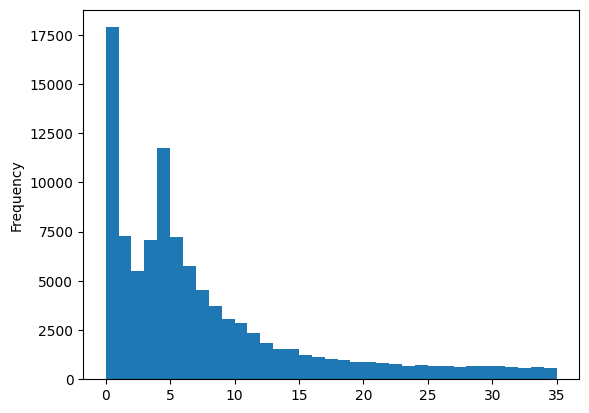

In [18]:
import matplotlib.pyplot as plt
y_train_st.plot(kind='hist', bins=35)
plt.show()

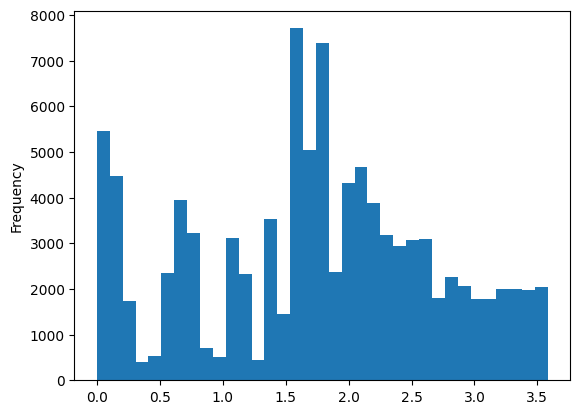

In [19]:
import matplotlib.pyplot as plt
np.log1p(y_train_st).plot(kind='hist', bins=35)
plt.show()

# Encode


1.   Encoding for Categorical Variables
2.   Categorical Variables that are ordinal remains the same (year, month)



### 1. Encoding Name

In [20]:
# 0 for NoName 1 for Name
X_train['Name'] = X_train['Name'].apply(lambda x: 0 if ('NoName' in x) else 1)
X_test['Name'] = X_test['Name'].apply(lambda x: 0 if ('NoName' in x) else 1)

### 2. Encoding City Found

In [21]:
# split to Austin, not Austin
X_train['City Found'] = X_train['City Found'].apply(lambda x: 'Austin' if ('Austin' in x) else 'NotAustin')
X_test['City Found'] = X_test['City Found'].apply(lambda x: 'Austin' if ('Austin' in x) else 'NotAustin')

In [22]:
# 1 for Austin for City Found
X_train['City Found'] = X_train['City Found'].apply(lambda x: 1 if (x=='Austin') else 0)
X_test['City Found'] = X_test['City Found'].apply(lambda x: 1 if (x=='Austin') else 0)

### 3. Encode Intake Type

Since we have 1 wildlife type, we ran code to check its outcome previously and found it was returned to owner, so we decided the wildlife type would be handled as stray.

In [23]:
X_train['Intake Type'] = X_train['Intake Type'].apply(lambda x: 'Stray' if ('Wildlife' in x) else x)
X_test['Intake Type'] = X_test['Intake Type'].apply(lambda x: 'Stray' if ('Wildlife' in x) else x)

In [24]:
# one hot encoding for Intake Type
X_train = pd.get_dummies(X_train, columns=['Intake Type'])
X_test = pd.get_dummies(X_test, columns=['Intake Type'])

### 4. Encoding Intake Condition

In [25]:
X_train['Intake Condition'] = X_train['Intake Condition'].apply(lambda x: 'Normal' if (x == 'Normal') else 'NotNormal')
X_test['Intake Condition'] = X_test['Intake Condition'].apply(lambda x: 'Normal' if (x == 'Normal') else 'NotNormal')

In [26]:
# 0 for normal 1 for NotNormal
X_train['Intake Condition'] = X_train['Intake Condition'].apply(lambda x: 0 if ('NotNormal' in x) else 1)
X_test['Intake Condition'] = X_test['Intake Condition'].apply(lambda x: 0 if ('NotNormal' in x) else 1)

### 5/6. Encode Sex Upon Intake


1.   Format to two colums: Gender, Intact Status
2.   Gender {Female, Male}, Intact Status {Intact, Spayed/Neutered}



create two new columns

In [27]:
X_train['Gender'] = X_train['Sex upon Intake'].apply(lambda x: 'Female' if ('Female' in x) else 'Male')
X_test['Gender'] = X_test['Sex upon Intake'].apply(lambda x: 'Female' if ('Female' in x) else 'Male')

In [28]:
X_train['Intact Status'] = X_train['Sex upon Intake'].apply(lambda x: 'Intact' if ('Intact' in x) else 'Spayed/Neutered')
X_test['Intact Status'] = X_test['Sex upon Intake'].apply(lambda x: 'Intact' if ('Intact' in x) else 'Spayed/Neutered')

Drop "Sex upon Intake" column

In [29]:
X_train.drop(columns=['Sex upon Intake'], inplace=True)
X_test.drop(columns=['Sex upon Intake'], inplace=True)

Encode Values

In [30]:
# 0 for Intact 1 for Spayed/Neutered
X_train['Intact Status'] = X_train['Intact Status'].apply(lambda x: 0 if ('Intact' in x) else 1)
X_test['Intact Status'] = X_test['Intact Status'].apply(lambda x: 0 if ('Intact' in x) else 1)

In [31]:
# 0 for Female 1 for Male
X_train['Gender'] = X_train['Gender'].apply(lambda x: 0 if ('Female' in x) else 1)
X_test['Gender'] = X_test['Gender'].apply(lambda x: 0 if ('Female' in x) else 1)

Since outcome type was dropped for stay prediction, no need to encode it.

### 7. Encode Animal Type

In [32]:
# one-hot encode animal type
X_train = pd.get_dummies(X_train, columns=['Animal Type'])
X_test = pd.get_dummies(X_test, columns=['Animal Type'])

### 8. Breed


1.   Cats can be separated by "Domestic" but dogs have more than 1000 breeds, and hard to encode
2.   Encoding done by using the one-hot encoding of the animal type, multiply by the cat breed, to create a new column of (Cat*Breed)



In [33]:
# handling breed: 0 for domestic cats or dogs, 1 for cats with breed

X_train['Breed'] = X_train['Breed'].apply(lambda x: 0 if ('Domestic' in x) else 1)
X_test['Breed'] = X_test['Breed'].apply(lambda x: 0 if ('Domestic' in x) else 1)

In [34]:
# for breed, create a new column: cat*breed, which means dogs will always have 0 in this column
X_train['Cat * Breed'] = X_train['Animal Type_Cat'] * X_train['Breed']
X_test['Cat * Breed'] = X_test['Animal Type_Cat'] * X_test['Breed']

In [35]:
# just to check the correctness, can be removed:
# X_test[(X_test['Breed'] == 1) & (X_test['Animal Type_Cat'] == True)]

Drop the breed column

In [36]:
X_train.drop(columns=['Breed'], inplace=True)
X_test.drop(columns=['Breed'], inplace=True)

### 9. color

In [37]:
X_train.shape

(99546, 21)

In [38]:
X_train[X_train['Color']=="Black"].shape # about 8%

(7700, 21)

In [39]:
# 1 for Black for Color
X_train['Color'] = X_train['Color'].apply(lambda x: 1 if (x=='Black') else 0)
X_test['Color'] = X_test['Color'].apply(lambda x: 1 if (x=='Black') else 0)

### 10/11 Year, Month -> Ordinal

### 12. Season

In [40]:
# one hot encoding for Season
X_train = pd.get_dummies(X_train, columns=['Season'])
X_test = pd.get_dummies(X_test, columns=['Season'])

### Inspect Columns

In [41]:
features = X_train.columns.to_list()
features

['Name',
 'City Found',
 'Times Taken Into Shelter',
 'Intake Condition',
 'Age upon Intake',
 'Color',
 'Year',
 'Month',
 'Day',
 'Hour',
 'Intake Type_Abandoned',
 'Intake Type_Euthanasia Request',
 'Intake Type_Owner Surrender',
 'Intake Type_Public Assist',
 'Intake Type_Stray',
 'Gender',
 'Intact Status',
 'Animal Type_Cat',
 'Animal Type_Dog',
 'Cat * Breed',
 'Season_Fall',
 'Season_Spring',
 'Season_Summer',
 'Season_Winter']

### Encode Ordinal Year

In [42]:
from sklearn.preprocessing import OrdinalEncoder

In [43]:
encoder = OrdinalEncoder()
X_train_ordYear = X_train.copy()
X_test_ordYear = X_test.copy()

encoder.fit(X_train[['Year']])
fit_train_year = encoder.transform(X_train[['Year']])
fit_test_year = encoder.transform(X_test[['Year']])

X_train['Year'] = fit_train_year
X_test['Year'] = fit_test_year

# Predict Stay Time

In [45]:
len(features)

24

In [46]:
# Import linear regression models
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
# Import confusion matrix function from sklearn
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

## Benchmark Simple Linear Regression Model

In [47]:
def run_model(mdl, X_train, X_test, y_train_data, y_test_data):
  mdl.fit(X_train, y_train_data)
  train_score = mdl.score(X_train, y_train_data)
  test_score = mdl.score(X_test, y_test_data)

  y_pred_train = mdl.predict(X_train)
  mse_train = mean_squared_error(y_train_data, y_pred_train)
  print(f"Mean Squared Error Train: {mse_train:.2f}")
  mae_train = mean_absolute_error(y_train_data, y_pred_train)
  print(f"Mean Absolute Error Train: {mae_train:.2f}")

  y_pred = mdl.predict(X_test)
  mse = mean_squared_error(y_test_data, y_pred)
  print(f"Mean Squared Error Test: {mse:.2f}")
  mae = mean_absolute_error(y_test_data, y_pred)
  print(f"Mean Absolute Error Test: {mae:.2f}")

  print('The score of this model over training data is {:.3f} and {:.3f} over the testing data'.format(train_score, test_score))

In [48]:
mdl = LinearRegression()
run_model(mdl, X_train, X_test, y_train_st, y_test_st)

Mean Squared Error Train: 58.56
Mean Absolute Error Train: 5.68
Mean Squared Error Test: 58.15
Mean Absolute Error Test: 5.66
The score of this model over training data is 0.098 and 0.105 over the testing data


## Test Other Models


1.   LassoCV
2.   RidgeCV
3.   DecisionTreeRegressor

DecisionTreeRegressor has the best training score, but is heavily overfitting, the testing MSE for all models are around 58, and MAE around 5.66



In [49]:
X_train.shape

(99546, 24)

In [50]:
mdl = LassoCV()
run_model(mdl, X_train, X_test, y_train_st, y_test_st)

Mean Squared Error Train: 58.57
Mean Absolute Error Train: 5.69
Mean Squared Error Test: 58.15
Mean Absolute Error Test: 5.66
The score of this model over training data is 0.098 and 0.105 over the testing data


In [51]:
mdl = RidgeCV()
run_model(mdl, X_train, X_test, y_train_st, y_test_st)

Mean Squared Error Train: 58.56
Mean Absolute Error Train: 5.68
Mean Squared Error Test: 58.15
Mean Absolute Error Test: 5.66
The score of this model over training data is 0.098 and 0.105 over the testing data


In [52]:
mdl = DecisionTreeRegressor(random_state=0)
run_model(mdl, X_train, X_test, y_train_st, y_test_st)

Mean Squared Error Train: 1.20
Mean Absolute Error Train: 0.19
Mean Squared Error Test: 87.52
Mean Absolute Error Test: 5.89
The score of this model over training data is 0.982 and -0.347 over the testing data


In [53]:
mdl = RandomForestRegressor(random_state=0)
run_model(mdl, X_train, X_test, y_train_st, y_test_st)

Mean Squared Error Train: 7.41
Mean Absolute Error Train: 1.84
Mean Squared Error Test: 45.58
Mean Absolute Error Test: 4.68
The score of this model over training data is 0.886 and 0.298 over the testing data


In [54]:
temp_f = ['Name',
 'City Found',
 'Times Taken Into Shelter',
 'Intake Condition',
 'Age upon Intake',
 'Color',
 'Intake Type_Abandoned',
 'Intake Type_Euthanasia Request',
 'Intake Type_Owner Surrender',
 'Intake Type_Public Assist',
 'Intake Type_Stray',
 'Gender',
 'Intact Status',
 'Animal Type_Cat',
 'Animal Type_Dog',
 'Cat * Breed',
 'Season_Fall',
 'Season_Spring',
 'Season_Summer',
 'Season_Winter']
mdl = DecisionTreeRegressor(random_state=0)
run_model(mdl, X_train[temp_f], X_test[temp_f], y_train_st, y_test_st)

Mean Squared Error Train: 43.13
Mean Absolute Error Train: 4.48
Mean Squared Error Test: 59.87
Mean Absolute Error Test: 5.43
The score of this model over training data is 0.336 and 0.078 over the testing data


In [55]:
temp_f = ['Name',
 'City Found',
 'Times Taken Into Shelter',
 'Intake Condition',
 'Age upon Intake',
 'Color',
 'Intake Type_Abandoned',
 'Intake Type_Euthanasia Request',
 'Intake Type_Owner Surrender',
 'Intake Type_Public Assist',
 'Intake Type_Stray',
 'Gender',
 'Intact Status',
 'Animal Type_Cat',
 'Animal Type_Dog',
 'Cat * Breed']
mdl = DecisionTreeRegressor(random_state=0)
run_model(mdl, X_train[temp_f], X_test[temp_f], y_train_st, y_test_st)

Mean Squared Error Train: 48.42
Mean Absolute Error Train: 4.91
Mean Squared Error Test: 56.14
Mean Absolute Error Test: 5.34
The score of this model over training data is 0.254 and 0.136 over the testing data


## Feature Engineering

### Feature Scaling

Results in Null values when using StandardScaler

In [56]:
from sklearn.preprocessing import StandardScaler

num_feature_col = ["Times Taken Into Shelter", 'Age upon Intake', 'Day', 'Hour']
def standardize_data(X_train, X_out_of_sample):
    """standardizes all of the data in X_train and X_out_of_sample. The mean and
    standard deviation of each feature (i.e., each column) from the X_train
    data is used to standardize both the X_train and X_out_of sample."""

    # Define scaling function
    scaler = StandardScaler()
    train = X_train.copy()
    test = X_out_of_sample.copy()

    '''Use scaler to standardize your data. You'll need to fit scaler with your
    training data (use the fit method) and standardize your training and
    out-of-sample data (use the transform method)'''

    scaler.fit(X_train[num_feature_col])
    # standardize only numerical features
    X_train_standardized = scaler.transform(X_train[num_feature_col])
    X_out_of_sample_standardized= scaler.transform(X_out_of_sample[num_feature_col])

    X_train_standardized = pd.DataFrame(X_train_standardized, columns =num_feature_col)
    X_out_of_sample_standardized = pd.DataFrame(X_out_of_sample_standardized, columns =num_feature_col)

    train[num_feature_col] = X_train_standardized
    test[num_feature_col] = X_out_of_sample_standardized


    return train, test, scaler

# Make new data that is scaled"
X_train_scaled, X_test_scaled, scaler = standardize_data(X_train, X_test)

In [58]:
X_train.head()

,Name,City Found,Times Taken Into Shelter,Intake Condition,Age upon Intake,Color,Year,Month,Day,Hour,...,Intake Type_Stray,Gender,Intact Status,Animal Type_Cat,Animal Type_Dog,Cat * Breed,Season_Fall,Season_Spring,Season_Summer,Season_Winter
77842,1,0,1,1,0.083,0,5.0,7,24,13,...,True,1,0,False,True,0,False,False,True,False
33217,1,1,1,1,0.083,0,2.0,9,23,11,...,True,0,0,True,False,1,True,False,False,False
21693,1,1,1,0,1.000,0,2.0,1,24,14,...,True,0,0,False,True,0,False,False,False,True
26584,1,1,1,1,0.038,0,2.0,5,21,11,...,True,0,0,True,False,0,False,True,False,False
2715,0,1,1,0,7.000,0,0.0,12,1,15,...,True,1,1,True,False,0,False,False,False,True


### Feature Combination

In [59]:
%%capture --no-stdout
# from sklearn.feature_selection import f_regression
# Create a list of F-values for the existing features
feature_F_scores, _ = f_regression(X_train, y_train_st)
top_5_f=np.zeros(5)
top_5_new_features = [None] * 5

# Iterate through each combination of features
for f1_index, f1 in enumerate(X_train.columns):
  for f2_index, f2 in enumerate(X_train.columns[f1_index + 1:]):
    # Multiply the two features to create a new feature
    new_feature = X_train[[f1]].multiply(X_train[f2], axis=0)
    # Evaluate F-value of new feature
    F_Score_new, p_value_new = f_regression(new_feature, y_train_st)
    # Evaluate the relative improvement of the new feature
    F_score_improvement = F_Score_new[0] / max(feature_F_scores[[f1_index, f2_index]])

    # Print out features that is sufficiently improved
    if F_score_improvement >= 1.5 and F_Score_new[0] >= 75 and p_value_new < 0.05:
        '''Note that F_score_improvement >= 1.5 and F_Score_new[0] >= 75 is
         relatively arbitrary, and that other values could be used.'''
        # print(f'{f1} + {f2} has an F-score of {F_Score_new[0]:.2f}')
        # print(f'\tBetter by a factor of {F_score_improvement:.2f} over features in isolation')
        # print(f'\tThe result is significant (p = {p_value_new})')
        if F_Score_new > top_5_f.min():
          index = top_5_f.argmin()
          top_5_f[index]=F_Score_new
          top_5_new_features[index]=f'{f1} + {f2}'

print(top_5_f, top_5_new_features)

[1185.46797432 1495.46032028 1405.28560719 1636.08695926  865.58764997] ['Intake Condition + Animal Type_Cat', 'Intake Type_Stray + Intact Status', 'Age upon Intake + Intake Type_Stray', 'Intake Condition + Year', 'Age upon Intake + Animal Type_Dog']


In [ ]:
def new_feature_combos(X):
    """
    Make a new set of X data by doing algorithmic feature engineering
    """

    # First, we make a copy of the original X features
    X_new = X.copy()

    X_new['Intake Condition * Animal Type_Cat'] = X_new['Intake Condition'] * X_new['Animal Type_Cat']
    X_new['Intake Type_Stray * Intact Status'] = X_new['Intake Type_Stray'] * X_new['Intact Status']
    X_new['Age upon Intake * Intake Type_Stray'] = X_new['Age upon Intake'] * X_new['Intake Type_Stray']
    X_new['Intake Condition * Year'] = X_new['Intake Condition'] * X_new['Year']
    X_new['Age upon Intake * Animal Type_Dog'] = X_new['Age upon Intake'] * X_new['Animal Type_Dog']
    return X_new

# Make new X features with interactions
X_train_fComb = new_feature_combos(X_train)
X_test_fComb = new_feature_combos(X_test)

In [ ]:
# Benchmark
mdl = RandomForestRegressor(random_state=0)
run_model(mdl, X_train_fComb, X_test_fComb, y_train_st, y_test_st)

Mean Squared Error Train: 7.40
Mean Absolute Error Train: 1.84
Mean Squared Error Test: 45.48
Mean Absolute Error Test: 4.68
The score of this model over training data is 0.886 and 0.300 over the testing data


### Feature Selection

**Current best, selectkbest k=15, randomforestregressor default**

Original dataset

In [ ]:
feature_F_scores, _ = f_regression(X_train, y_train_st)
select_k_features = SelectKBest(score_func=f_regression)
select_k_features.fit(X_train, y_train_st)
mask = select_k_features.get_support()
new_features_kept = X_train.columns[mask].to_list()
print(new_features_kept)

['Name', 'City Found', 'Intake Condition', 'Age upon Intake', 'Year', 'Intake Type_Owner Surrender', 'Intake Type_Stray', 'Intact Status', 'Animal Type_Cat', 'Animal Type_Dog']


In [ ]:
mdl = DecisionTreeRegressor(random_state=0)
run_model(mdl, X_train[new_features_kept], X_test[new_features_kept], y_train_st, y_test_st)

Mean Squared Error Train: 44.28
Mean Absolute Error Train: 4.60
Mean Squared Error Test: 54.49
Mean Absolute Error Test: 5.15
The score of this model over training data is 0.318 and 0.161 over the testing data


In [ ]:
# Current best
mdl = RandomForestRegressor(random_state=0)
run_model(mdl, X_train[new_features_kept], X_test[new_features_kept], y_train_st, y_test_st)

Mean Squared Error Train: 44.67
Mean Absolute Error Train: 4.69
Mean Squared Error Test: 52.68
Mean Absolute Error Test: 5.11
The score of this model over training data is 0.312 and 0.189 over the testing data


In [ ]:
feature_F_scores, _ = f_regression(X_train, y_train_st)
select_k_features = SelectKBest(score_func=f_regression, k=15)
select_k_features.fit(X_train, y_train_st)
mask = select_k_features.get_support()
new_features_kept = X_train.columns[mask].to_list()
print(new_features_kept)

['Name', 'City Found', 'Intake Condition', 'Age upon Intake', 'Year', 'Month', 'Intake Type_Abandoned', 'Intake Type_Euthanasia Request', 'Intake Type_Owner Surrender', 'Intake Type_Public Assist', 'Intake Type_Stray', 'Intact Status', 'Animal Type_Cat', 'Animal Type_Dog', 'Season_Summer']


### Skew Data

In [ ]:
a = np.log1p(1.6)
b = np.expm1(a)

In [ ]:
a

0.9555114450274365

In [ ]:
b

1.6000000000000003

In [ ]:
def run_model_with_normalize(mdl, X_train, X_test, y_train_data, y_test_data):
  mdl.fit(X_train, np.log1p(y_train_data))
  train_score = mdl.score(X_train, np.log1p(y_train_data))
  test_score = mdl.score(X_test, np.log1p(y_test_data))

  y_pred_train = mdl.predict(X_train)
  y_pred_train = np.expm1(y_pred_train)
  mse_train = mean_squared_error(y_train_data, y_pred_train)
  print(f"Mean Squared Error Train: {mse_train:.2f}")
  mae_train = mean_absolute_error(y_train_data, y_pred_train)
  print(f"Mean Absolute Error Train: {mae_train:.2f}")

  y_pred = mdl.predict(X_test)
  y_pred = np.expm1(y_pred)
  mse = mean_squared_error(y_test_data, y_pred)
  print(f"Mean Squared Error Test: {mse:.2f}")
  mae = mean_absolute_error(y_test_data, y_pred)
  print(f"Mean Absolute Error Test: {mae:.2f}")

  print('The score of this model over training data is {:.3f} and {:.3f} over the testing data'.format(train_score, test_score))

In [ ]:
mdl = DecisionTreeRegressor(random_state=0)
run_model_with_normalize(mdl, X_train, X_test, y_train_st, y_test_st)

Mean Squared Error Train: 1.33
Mean Absolute Error Train: 0.19
Mean Squared Error Test: 85.21
Mean Absolute Error Test: 5.82


In [ ]:
# best with log normalize
mdl = RandomForestRegressor(random_state=0)
run_model_with_normalize(mdl, X_train, X_test, y_train_st, y_test_st)

Mean Squared Error Train: 13.50
Mean Absolute Error Train: 1.96
Mean Squared Error Test: 48.62
Mean Absolute Error Test: 4.32


## Hyperparameter Tuning with GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

params_to_search = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15],
    'max_features': ['sqrt', 'log2', None],
}

# Initialize a model
mdl = RandomForestRegressor(random_state=0)
# Initialize the grid search
optimized_dt = GridSearchCV(mdl, params_to_search, scoring = ['neg_mean_squared_error', 'neg_mean_absolute_error'], refit=False, cv=5)
# Run the grid search
optimized_dt.fit(X_train[new_features_kept], y_train_st)


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=0),
             param_grid={'max_depth': [10, 15],
                         'max_features': ['sqrt', 'log2', None],
                         'n_estimators': [50, 100]},
             refit=False,
             scoring=['neg_mean_squared_error', 'neg_mean_absolute_error'])

In [ ]:
results = optimized_dt.cv_results_
mean_test_score = results["mean_test_neg_mean_squared_error"]
highest = mean_test_score.argmax()

print(f'The best model has a score of {mean_test_score.max():.3f}')
print('The best model has the parameters: ', results['params'][highest])

mean_test_score_abs = results["mean_test_neg_mean_absolute_error"]
highest = mean_test_score_abs.argmax()

print(f'The best model has a score of {mean_test_score_abs.max():.3f}')
print('The best model has the parameters: ', results['params'][highest])

The best model has a score of -49.324
The best model has the parameters:  {'max_depth': 15, 'max_features': 'sqrt', 'n_estimators': 100}
The best model has a score of -4.975
The best model has the parameters:  {'max_depth': 15, 'max_features': None, 'n_estimators': 100}


In [ ]:
mdl = RandomForestRegressor(max_depth = 15, max_features = "sqrt", n_estimators = 200, random_state=0)
run_model(mdl, X_train[new_features_kept], X_test[new_features_kept], y_train_st, y_test_st)

Mean Squared Error Train: 40.86
Mean Absolute Error Train: 4.51
Mean Squared Error Test: 47.34
Mean Absolute Error Test: 4.88
The score of this model over training data is 0.371 and 0.271 over the testing data


In [ ]:
# FINAL BEST MODEL ################
mdl = RandomForestRegressor(max_depth = 15, n_estimators = 100, random_state=0)
run_model_with_normalize(mdl, X_train[new_features_kept], X_test[new_features_kept], y_train_st, y_test_st)

Mean Squared Error Train: 48.14
Mean Absolute Error Train: 4.30
Mean Squared Error Test: 53.02
Mean Absolute Error Test: 4.60
The score of this model over training data is 0.445 and 0.338 over the testing data


In [ ]:
feature_names = X_train[new_features_kept].columns[:]
print(feature_names)

importance = mdl.feature_importances_
feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importances.sort_values('Importance', ascending = False)

Index(['Name', 'City Found', 'Intake Condition', 'Age upon Intake', 'Year',
       'Month', 'Intake Type_Abandoned', 'Intake Type_Euthanasia Request',
       'Intake Type_Owner Surrender', 'Intake Type_Public Assist',
       'Intake Type_Stray', 'Intact Status', 'Animal Type_Cat',
       'Animal Type_Dog', 'Season_Summer'],
      dtype='object')


,Feature,Importance
3,Age upon Intake,0.316544
4,Year,0.151092
5,Month,0.122102
11,Intact Status,0.078225
0,Name,0.060740
10,Intake Type_Stray,0.054605
13,Animal Type_Dog,0.047778
2,Intake Condition,0.047665
12,Animal Type_Cat,0.038435
1,City Found,0.027083


In [ ]:
(5.66-4.6)/5.66

0.18727915194346298

In [ ]:
mdl = RandomForestRegressor(max_depth = 15, n_estimators = 200, random_state=0)
run_model_with_normalize(mdl, X_train[new_features_kept], X_test[new_features_kept], y_train_st, y_test_st)

Mean Squared Error Train: 48.14
Mean Absolute Error Train: 4.30
Mean Squared Error Test: 52.98
Mean Absolute Error Test: 4.60
The score of this model over training data is 0.446 and 0.338 over the testing data


In [ ]:
best_mdl_stay_time = RandomForestRegressor(max_depth = 15, n_estimators = 100, random_state=0)
run_model(best_mdl_stay_time, X_train[new_features_kept], X_test[new_features_kept], y_train_st, y_test_st)

Mean Squared Error Train: 39.92
Mean Absolute Error Train: 4.41
Mean Squared Error Test: 47.61
Mean Absolute Error Test: 4.85
The score of this model over training data is 0.385 and 0.267 over the testing data


In [ ]:
# Best Model
best_mdl_stay_time = RandomForestRegressor(max_depth = 15, n_estimators = 200, random_state=0)
run_model(best_mdl_stay_time, X_train[new_features_kept], X_test[new_features_kept], y_train_st, y_test_st)

Mean Squared Error Train: 39.88
Mean Absolute Error Train: 4.41
Mean Squared Error Test: 47.60
Mean Absolute Error Test: 4.85
The score of this model over training data is 0.386 and 0.267 over the testing data


In [ ]:
# Best Model
best_mdl_stay_time = RandomForestRegressor(max_depth = 15, n_estimators = 200, random_state=0)
best_mdl_stay_time.fit(X_train[new_features_kept],y_train_st)
# run_model(best_mdl_stay_time, X_train[new_features_kept], X_test[new_features_kept], y_train_st, y_test_st)

RandomForestRegressor(max_depth=15, n_estimators=200, random_state=0)

In [ ]:
sample = X_train[new_features_kept].iloc[0]
outcome = best_mdl_stay_time.predict(sample.to_frame().T)
outcome

array([8.31050532])

In [ ]:
sample

,77842
Name,1
City Found,0
Intake Condition,1
Age upon Intake,0.083
Year,5.0
Month,7
Intake Type_Abandoned,False
Intake Type_Euthanasia Request,False
Intake Type_Owner Surrender,False
Intake Type_Public Assist,False


# Predict Outcome

Append time to X_train

In [ ]:
X_train_outcome = X_train.copy()
X_test_outcome = X_test.copy()

X_train_outcome["Stay_days"] = y_train["Stay_days"]
X_test_outcome["Stay_days"] = y_test["Stay_days"]

In [ ]:
y_train_ot.unique()

array(['Adoption', 'Transfer', 'Euthanasia', 'Return to Owner', 'Died',
       'Rto-Adopt', 'Disposal', 'Missing', 'Relocate', 'Stolen'],
      dtype=object)

In [ ]:
y_test_ot.unique()

array(['Adoption', 'Transfer', 'Return to Owner', 'Euthanasia', 'Died',
       'Relocate', 'Rto-Adopt', 'Missing', 'Disposal', 'Lost', 'Stolen'],
      dtype=object)

In [ ]:
y_test_ot[y_test_ot == "Lost"] = "Missing"

<ipython-input-49-159330f17244>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test_ot[y_test_ot == "Lost"] = "Missing"


In [ ]:
y_test_ot.unique()

array(['Adoption', 'Transfer', 'Return to Owner', 'Euthanasia', 'Died',
       'Relocate', 'Rto-Adopt', 'Missing', 'Disposal', 'Stolen'],
      dtype=object)

## Benchmark

In [ ]:
def run_model_classifier(mdl, X_train, X_test, y_train_data, y_test_data):
  mdl.fit(X_train, y_train_data)
  train_score = mdl.score(X_train, y_train_data)
  test_score = mdl.score(X_test, y_test_data)

  y_pred_train = mdl.predict(X_train)
  pre_train = precision_score(y_train_data, y_pred_train, average="weighted", zero_division=0)
  print(f"precision Train: {pre_train:.2f}")
  rec_train = recall_score(y_train_data, y_pred_train, average="weighted", zero_division=0)
  print(f"recall Train: {rec_train:.2f}")
  f1_train = f1_score(y_train_data, y_pred_train, average="weighted", zero_division=0)
  print(f"f1 Train: {f1_train:.2f}")

  y_pred = mdl.predict(X_test)
  pre = precision_score(y_test_data, y_pred, average="weighted", zero_division=0)
  print(f"precision Test: {pre:.2f}")
  rec = recall_score(y_test_data, y_pred, average="weighted", zero_division=0)
  print(f"recall Test: {rec:.2f}")
  f1 = f1_score(y_test_data, y_pred, average="weighted", zero_division=0)
  print(f"f1 Test: {f1:.2f}")

  print('The score of this model over training data is {:.3f} and {:.3f} over the testing data'.format(train_score, test_score))

In [ ]:
mdl = DecisionTreeClassifier()
run_model_classifier(mdl, X_train, X_test, y_train_ot, y_test_ot)

precision Train: 0.99
recall Train: 0.99
f1 Train: 0.99
precision Test: 0.60
recall Test: 0.60
f1 Test: 0.60
The score of this model over training data is 0.991 and 0.601 over the testing data


In [ ]:
mdl = DecisionTreeClassifier()
run_model_classifier(mdl, X_train_outcome, X_test_outcome, y_train_ot, y_test_ot)

precision Train: 1.00
recall Train: 1.00
f1 Train: 1.00
precision Test: 0.71
recall Test: 0.71
f1 Test: 0.71
The score of this model over training data is 1.000 and 0.711 over the testing data


In [ ]:
mdl = DecisionTreeClassifier(max_depth=10)
run_model_classifier(mdl, X_train_outcome, X_test_outcome, y_train_ot, y_test_ot)

precision Train: 0.78
recall Train: 0.77
f1 Train: 0.75
precision Test: 0.76
recall Test: 0.76
f1 Test: 0.74
The score of this model over training data is 0.767 and 0.759 over the testing data


In [ ]:
mdl = DecisionTreeClassifier(max_depth=10, class_weight = "balanced")
run_model_classifier(mdl, X_train_outcome, X_test_outcome, y_train_ot, y_test_ot)

precision Train: 0.76
recall Train: 0.48
f1 Train: 0.57
precision Test: 0.75
recall Test: 0.47
f1 Test: 0.56
The score of this model over training data is 0.480 and 0.469 over the testing data


In [ ]:
mdl = RandomForestClassifier()
run_model_classifier(mdl, X_train_outcome, X_test_outcome, y_train_ot, y_test_ot)

precision Train: 1.00
recall Train: 1.00
f1 Train: 1.00
precision Test: 0.79
recall Test: 0.79
f1 Test: 0.78
The score of this model over training data is 1.000 and 0.790 over the testing data


In [ ]:
mdl = RandomForestClassifier(max_depth=10)
run_model_classifier(mdl, X_train_outcome, X_test_outcome, y_train_ot, y_test_ot)

precision Train: 0.79
recall Train: 0.76
f1 Train: 0.74
precision Test: 0.77
recall Test: 0.76
f1 Test: 0.74
The score of this model over training data is 0.761 and 0.758 over the testing data


In [ ]:
mdl = RandomForestClassifier(class_weight = "balanced")
run_model_classifier(mdl, X_train_outcome, X_test_outcome, y_train_ot, y_test_ot)

precision Train: 1.00
recall Train: 1.00
f1 Train: 1.00
precision Test: 0.79
recall Test: 0.79
f1 Test: 0.78
The score of this model over training data is 1.000 and 0.788 over the testing data


### Feature Combination

In [ ]:
%%capture --no-stdout
# from sklearn.feature_selection import f_regression
# Create a list of F-values for the existing features
feature_F_scores, _ = f_classif(X_train_outcome, y_train_ot)
top_5_f=np.zeros(5)
top_5_new_features = [None] * 5

# Iterate through each combination of features
for f1_index, f1 in enumerate(X_train_outcome.columns):
  for f2_index, f2 in enumerate(X_train_outcome.columns[f1_index + 1:]):
    # Multiply the two features to create a new feature
    new_feature = X_train_outcome[[f1]].multiply(X_train_outcome[f2], axis=0)
    # Evaluate F-value of new feature
    F_Score_new, p_value_new = f_classif(new_feature, y_train_ot)
    # Evaluate the relative improvement of the new feature
    F_score_improvement = F_Score_new[0] / max(feature_F_scores[[f1_index, f2_index]])

    # Print out features that is sufficiently improved
    if F_score_improvement >= 1.5 and F_Score_new[0] >= 75 and p_value_new < 0.05:
        '''Note that F_score_improvement >= 1.5 and F_Score_new[0] >= 75 is
         relatively arbitrary, and that other values could be used.'''
        # print(f'{f1} + {f2} has an F-score of {F_Score_new[0]:.2f}')
        # print(f'\tBetter by a factor of {F_score_improvement:.2f} over features in isolation')
        # print(f'\tThe result is significant (p = {p_value_new})')
        if F_Score_new > top_5_f.min():
          index = top_5_f.argmin()
          top_5_f[index]=F_Score_new
          top_5_new_features[index]=f'{f1} + {f2}'

print(top_5_f, top_5_new_features)

[1381.49983272 1289.20548513 1409.8470459  1746.84209392 1446.34117044] ['Intake Type_Stray + Intact Status', 'Intake Type_Stray + Stay_days', 'Intake Type_Stray + Animal Type_Cat', 'Hour + Stay_days', 'City Found + Intake Type_Public Assist']


In [ ]:
def new_feature_combos(X):
    """
    Make a new set of X data by doing algorithmic feature engineering
    """

    # First, we make a copy of the original X features
    X_new = X.copy()

    # ----------------------------------------------------------
    X_new['Intake Type_Stray * Intact Status'] = X_new['Intake Type_Stray'] * X_new['Intact Status']
    X_new['Intake Type_Stray * Stay_days'] = X_new['Intake Type_Stray'] * X_new['Stay_days']
    X_new['Animal Type_Cat * Intake Type_Stray'] = X_new['Animal Type_Cat'] * X_new['Intake Type_Stray']
    X_new['Hour * Stay_days'] = X_new['Hour'] * X_new['Stay_days']
    X_new['City Found * Intake Type_Public Assist'] = X_new['City Found'] * X_new['Intake Type_Public Assist']
    # ----------------------------------------------------------
    return X_new

# Make new X features with interactions
X_train_fComb = new_feature_combos(X_train_outcome)
X_test_fComb = new_feature_combos(X_test_outcome)

In [ ]:
mdl = DecisionTreeClassifier(max_depth=10)
run_model_classifier(mdl, X_train_fComb, X_test_fComb, y_train_ot, y_test_ot)

precision Train: 0.78
recall Train: 0.77
f1 Train: 0.75
precision Test: 0.76
recall Test: 0.76
f1 Test: 0.74
The score of this model over training data is 0.768 and 0.759 over the testing data


In [ ]:
mdl = DecisionTreeClassifier(max_depth=10)
mdl.fit(X_train_fComb, y_train_ot)

sample = X_train_fComb.iloc[0]
outcome = mdl.predict(sample.to_frame().T)
outcome

array(['Adoption'], dtype=object)

In [ ]:
sample

In [ ]:
mdl = RandomForestClassifier(max_depth=10)
run_model_classifier(mdl, X_train_fComb, X_test_fComb, y_train_ot, y_test_ot)

precision Train: 0.79
recall Train: 0.76
f1 Train: 0.74
precision Test: 0.78
recall Test: 0.76
f1 Test: 0.74
The score of this model over training data is 0.762 and 0.759 over the testing data


In [ ]:
##### Best Model
mdl = RandomForestClassifier(max_depth=10, n_estimators=100, random_state = 0)
run_model_classifier(mdl, X_train_fComb, X_test_fComb, y_train_ot, y_test_ot)

precision Train: 0.79
recall Train: 0.76
f1 Train: 0.74
precision Test: 0.78
recall Test: 0.76
f1 Test: 0.74
The score of this model over training data is 0.763 and 0.760 over the testing data


In [ ]:
mdl = RandomForestClassifier(max_depth=10, n_estimators=100, random_state = 0)
mdl.fit(X_train_fComb, y_train_ot)
y_pred = mdl.predict(X_test_fComb)

In [ ]:
feature_names = X_train_fComb.columns[:]
print(feature_names)

importance = mdl.feature_importances_
feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importances.sort_values('Importance', ascending = False)

Index(['Name', 'City Found', 'Times Taken Into Shelter', 'Intake Condition',
       'Age upon Intake', 'Color', 'Year', 'Month', 'Day', 'Hour',
       'Intake Type_Abandoned', 'Intake Type_Euthanasia Request',
       'Intake Type_Owner Surrender', 'Intake Type_Public Assist',
       'Intake Type_Stray', 'Gender', 'Intact Status', 'Animal Type_Cat',
       'Animal Type_Dog', 'Cat * Breed', 'Season_Fall', 'Season_Spring',
       'Season_Summer', 'Season_Winter', 'Stay_days',
       'Intake Type_Stray * Intact Status', 'Intake Type_Stray * Stay_days',
       'Animal Type_Cat * Intake Type_Stray', 'Hour * Stay_days',
       'City Found * Intake Type_Public Assist'],
      dtype='object')


,Feature,Importance
24,Stay_days,0.161394
28,Hour * Stay_days,0.121573
4,Age upon Intake,0.116371
26,Intake Type_Stray * Stay_days,0.108797
0,Name,0.087113
12,Intake Type_Owner Surrender,0.066115
13,Intake Type_Public Assist,0.052816
25,Intake Type_Stray * Intact Status,0.034513
27,Animal Type_Cat * Intake Type_Stray,0.034053
14,Intake Type_Stray,0.031800


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true= y_test_ot, y_pred= y_pred, labels = y_test_ot.unique())
acc_by_class = cm.diagonal()/cm.sum(axis=1)

In [ ]:
y_test_ot.unique()

array(['Adoption', 'Transfer', 'Return to Owner', 'Euthanasia', 'Died',
       'Relocate', 'Rto-Adopt', 'Missing', 'Disposal', 'Stolen'],
      dtype=object)

In [ ]:
acc_by_class

array([0.96840499, 0.52068032, 0.81499169, 0.2097429 , 0.00534759,
       0.        , 0.        , 0.        , 0.03571429, 0.        ])

In [ ]:
precision_by_class = precision_score(y_true= y_test_ot, y_pred= y_pred, average = None)
precision_by_class

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([0.70195185, 1.        , 1.        , 0.85635359, 0.        ,
       0.        , 0.89468885, 0.        , 0.        , 0.8168587 ])

In [ ]:
recall_by_class = recall_score(y_true= y_test_ot, y_pred= y_pred, average = None)
recall_by_class

array([0.96840499, 0.00534759, 0.03571429, 0.2097429 , 0.        ,
       0.        , 0.81499169, 0.        , 0.        , 0.52068032])

In [ ]:
f1_by_class = f1_score(y_true= y_test_ot, y_pred= y_pred, average = None)
f1_by_class

array([0.81392629, 0.0106383 , 0.06896552, 0.33695652, 0.        ,
       0.        , 0.85298272, 0.        , 0.        , 0.63597734])

In [ ]:
mdl = RandomForestClassifier(max_depth=15, n_estimators=100)
run_model_classifier(mdl, X_train_fComb, X_test_fComb, y_train_ot, y_test_ot)

precision Train: 0.85
recall Train: 0.83
f1 Train: 0.82
precision Test: 0.79
recall Test: 0.77
f1 Test: 0.76
The score of this model over training data is 0.828 and 0.774 over the testing data


In [ ]:
# from sklearn.linear_model import LogisticRegressionCV
# mdl = LogisticRegressionCV(multi_class="multinomial")
# run_model_classifier(mdl, X_train_fComb, X_test_fComb, y_train_ot, y_test_ot)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
mdl = GradientBoostingClassifier()
run_model_classifier(mdl, X_train_fComb, X_test_fComb, y_train_ot, y_test_ot)

precision Train: 0.78
recall Train: 0.76
f1 Train: 0.75
precision Test: 0.77
recall Test: 0.76
f1 Test: 0.75
The score of this model over training data is 0.765 and 0.763 over the testing data


In [ ]:
mdl = GradientBoostingClassifier()
run_model_classifier(mdl, X_train_outcome, X_test_outcome, y_train_ot, y_test_ot)

## Feature Selection

In [ ]:
feature_F_scores, _ = f_classif(X_train_outcome, y_train_ot)
select_k_features = SelectKBest(score_func=f_classif)
select_k_features.fit(X_train_outcome, y_train_ot)
mask = select_k_features.get_support()
new_features_kept = X_train_outcome.columns[mask].to_list()
print(new_features_kept)

['Name', 'Intake Condition', 'Age upon Intake', 'Intake Type_Euthanasia Request', 'Intake Type_Owner Surrender', 'Intake Type_Public Assist', 'Intact Status', 'Animal Type_Cat', 'Animal Type_Dog', 'Stay_days']


In [ ]:
mdl = RandomForestClassifier(max_depth=10)
run_model_classifier(mdl, X_train_outcome[new_features_kept], X_test_outcome[new_features_kept], y_train_ot, y_test_ot)

precision Train: 0.78
recall Train: 0.76
f1 Train: 0.74
precision Test: 0.78
recall Test: 0.76
f1 Test: 0.74
The score of this model over training data is 0.762 and 0.759 over the testing data


In [ ]:
mdl = RandomForestClassifier(class_weight = "balanced")
run_model_classifier(mdl, X_train_outcome[new_features_kept], X_test_outcome[new_features_kept], y_train_ot, y_test_ot)

precision Train: 0.99
recall Train: 0.99
f1 Train: 0.99
precision Test: 0.71
recall Test: 0.71
f1 Test: 0.71
The score of this model over training data is 0.988 and 0.710 over the testing data


## Gridsearch

In [ ]:
y_train_ot.unique()

array(['Adoption', 'Transfer', 'Euthanasia', 'Return to Owner', 'Died',
       'Rto-Adopt', 'Disposal', 'Missing', 'Relocate', 'Stolen'],
      dtype=object)

In [ ]:
# from sklearn.model_selection import GridSearchCV

params_to_search = {
    'n_estimators': [50, 100],
    'max_depth': [10],
    'max_features': ['sqrt'],
    'class_weight' : ["balanced", None]
}

# Initialize a model
mdl = RandomForestClassifier(random_state=0)
# Initialize the grid search
optimized_dt = GridSearchCV(mdl, params_to_search, scoring = ['recall_weighted', 'precision_weighted'], refit=False, cv=5)
# Run the grid search
optimized_dt.fit(X_train_outcome[new_features_kept], y_train_ot)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predic

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0),
             param_grid={'class_weight': ['balanced', None], 'max_depth': [10],
                         'max_features': ['sqrt'], 'n_estimators': [50, 100]},
             refit=False, scoring=['recall_weighted', 'precision_weighted'])

In [ ]:
optimized_dt.cv_results_

{'mean_fit_time': array([3.73921771, 6.76667862, 3.25796256, 7.12905412]),
 'std_fit_time': array([0.85966346, 0.62332173, 0.50529213, 1.46391479]),
 'mean_score_time': array([0.4364862 , 0.53079081, 0.43928065, 0.60004468]),
 'std_score_time': array([0.00486646, 0.00510564, 0.01466709, 0.13756931]),
 'param_class_weight': masked_array(data=['balanced', 'balanced', None, None],
              mask=[False, False, False, False],
        fill_value='?',
             dtype=object),
 'param_max_depth': masked_array(data=[10, 10, 10, 10],
              mask=[False, False, False, False],
        fill_value=999999),
 'param_max_features': masked_array(data=['sqrt', 'sqrt', 'sqrt', 'sqrt'],
              mask=[False, False, False, False],
        fill_value='?',
             dtype=object),
 'param_n_estimators': masked_array(data=[50, 100, 50, 100],
              mask=[False, False, False, False],
        fill_value=999999),
 'params': [{'class_weight': 'balanced',
   'max_depth': 10,
   'max_fe

In [ ]:
results = optimized_dt.cv_results_
mean_test_score = results["mean_test_neg_mean_squared_error"]
highest = mean_test_score.argmax()

print(f'The best model has a score of {mean_test_score.max():.3f}')
print('The best model has the parameters: ', results['params'][highest])

mean_test_score_abs = results["mean_test_neg_mean_absolute_error"]
highest = mean_test_score_abs.argmax()

print(f'The best model has a score of {mean_test_score_abs.max():.3f}')
print('The best model has the parameters: ', results['params'][highest])

## Manual Test

In [ ]:
mdl = RandomForestClassifier(max_depth=15, class_weight = "balanced", n_estimators = 50, max_features = "sqrt")
run_model_classifier(mdl, X_train_outcome, X_test_outcome, y_train_ot, y_test_ot)

precision Train: 0.85
recall Train: 0.79
f1 Train: 0.81
precision Test: 0.77
recall Test: 0.71
f1 Test: 0.73
The score of this model over training data is 0.794 and 0.713 over the testing data


In [ ]:
mdl = RandomForestClassifier(max_depth=15, class_weight = "balanced", n_estimators = 50, max_features = "sqrt")
run_model_classifier(mdl, X_train_outcome[new_features_kept], X_test_outcome[new_features_kept], y_train_ot, y_test_ot)

precision Train: 0.83
recall Train: 0.73
f1 Train: 0.76
precision Test: 0.77
recall Test: 0.67
f1 Test: 0.71
The score of this model over training data is 0.730 and 0.670 over the testing data


In [ ]:
mdl = RandomForestClassifier(max_depth=10, class_weight = "balanced", n_estimators = 50, max_features = "sqrt")
run_model_classifier(mdl, X_train_outcome[new_features_kept], X_test_outcome[new_features_kept], y_train_ot, y_test_ot)

precision Train: 0.79
recall Train: 0.58
f1 Train: 0.65
precision Test: 0.79
recall Test: 0.57
f1 Test: 0.65
The score of this model over training data is 0.581 and 0.573 over the testing data


In [ ]:
mdl = RandomForestClassifier(max_depth=10, class_weight = "balanced", n_estimators = 150, max_features = "sqrt")
run_model_classifier(mdl, X_train_outcome[new_features_kept], X_test_outcome[new_features_kept], y_train_ot, y_test_ot)

precision Train: 0.79
recall Train: 0.58
f1 Train: 0.65
precision Test: 0.79
recall Test: 0.58
f1 Test: 0.65
The score of this model over training data is 0.584 and 0.575 over the testing data


In [ ]:
mdl = RandomForestClassifier(max_depth=15, class_weight = "balanced", n_estimators = 150, max_features = "sqrt")
run_model_classifier(mdl, X_train_outcome[new_features_kept], X_test_outcome[new_features_kept], y_train_ot, y_test_ot)

precision Train: 0.83
recall Train: 0.73
f1 Train: 0.76
precision Test: 0.77
recall Test: 0.67
f1 Test: 0.71
The score of this model over training data is 0.726 and 0.667 over the testing data


In [ ]:
mdl = LogisticRegression(random_state=0, solver='saga', max_iter=200)
run_model_classifier(mdl, X_train_outcome[new_features_kept], X_test_outcome[new_features_kept], y_train_ot, y_test_ot)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


precision Train: 0.66
recall Train: 0.68
f1 Train: 0.67
precision Test: 0.67
recall Test: 0.69
f1 Test: 0.67
The score of this model over training data is 0.683 and 0.689 over the testing data


In [ ]:
mdl = LogisticRegression(random_state=0, penalty='l1', solver='saga', class_weight='balanced', max_iter=500)
run_model_classifier(mdl, X_train_outcome[new_features_kept], X_test_outcome[new_features_kept], y_train_ot, y_test_ot)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


precision Train: 0.42
recall Train: 0.19
f1 Train: 0.24
precision Test: 0.42
recall Test: 0.18
f1 Test: 0.23
The score of this model over training data is 0.187 and 0.181 over the testing data
